In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

# confirm GPU is available
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


In [4]:
df = pd.read_csv('adhdata.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nClass distribution:")
print(df.groupby('ID')['Class'].first().value_counts())
print("\nUnique subjects:", df['ID'].nunique())

Shape: (2166383, 21)

Columns: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'Class', 'ID']

Class distribution:
Class
ADHD       61
Control    60
Name: count, dtype: int64

Unique subjects: 121


## 1. Preprocessing
Steps:
- Normalise each channel (zero mean, unit variance) per subject
- Slice into fixed-length windows across time
- Label each window with the subject's class
- Split into train / validation / test sets (subject-level split)

In [5]:
CHANNELS = ['Fp1','Fp2','F3','F4','C3','C4','P3','P4',
            'O1','O2','F7','F8','T7','T8','P7','P8','Fz','Cz','Pz']

WINDOW_SIZE = 128   # 1 second at 128 Hz
STEP_SIZE   = 64    # 50% overlap
MAX_WINDOWS = 200   # cap per subject to avoid imbalance

X, y, subject_ids = [], [], []

for subject_id, group in df.groupby('ID'):
    label = 1 if group['Class'].iloc[0] == 'ADHD' else 0
    signal = group[CHANNELS].values.astype(np.float32)

    # normalise per subject (zero mean, unit variance per channel)
    signal = (signal - signal.mean(axis=0)) / (signal.std(axis=0) + 1e-8)

    # slice into windows
    windows = []
    for start in range(0, len(signal) - WINDOW_SIZE, STEP_SIZE):
        windows.append(signal[start : start + WINDOW_SIZE])

    # cap windows per subject
    if len(windows) > MAX_WINDOWS:
        indices = np.random.choice(len(windows), MAX_WINDOWS, replace=False)
        windows = [windows[i] for i in sorted(indices)]

    X.extend(windows)
    y.extend([label] * len(windows))
    subject_ids.extend([subject_id] * len(windows))

X = np.array(X)   # shape: (n_windows, 128, 19)
y = np.array(y)

print(f"Total windows:    {len(X)}")
print(f"Window shape:     {X[0].shape}")
print(f"ADHD windows:     {y.sum()}")
print(f"Control windows:  {(y == 0).sum()}")
print(f"Class ratio:      {y.mean():.2f}")

Total windows:    23583
Window shape:     (128, 19)
ADHD windows:     11900
Control windows:  11683
Class ratio:      0.50


In [6]:
from sklearn.model_selection import train_test_split

# get unique subjects and their labels for subject-level splitting
subject_df = df.groupby('ID')['Class'].first().reset_index()
subject_df['label'] = (subject_df['Class'] == 'ADHD').astype(int)

# split subjects (not windows) to prevent data leakage
train_subjects, test_subjects = train_test_split(
    subject_df['ID'].values,
    test_size=0.15,
    stratify=subject_df['label'].values,
    random_state=42
)
train_subjects, val_subjects = train_test_split(
    train_subjects,
    test_size=0.15,
    stratify=subject_df[subject_df['ID'].isin(train_subjects)]['label'].values,
    random_state=42
)

subject_ids = np.array(subject_ids)

X_train = X[np.isin(subject_ids, train_subjects)]
y_train = y[np.isin(subject_ids, train_subjects)]

X_val   = X[np.isin(subject_ids, val_subjects)]
y_val   = y[np.isin(subject_ids, val_subjects)]

X_test  = X[np.isin(subject_ids, test_subjects)]
y_test  = y[np.isin(subject_ids, test_subjects)]

print(f"Train: {len(X_train)} windows ({len(train_subjects)} subjects)")
print(f"Val:   {len(X_val)} windows ({len(val_subjects)} subjects)")
print(f"Test:  {len(X_test)} windows ({len(test_subjects)} subjects)")

Train: 16744 windows (86 subjects)
Val:   3186 windows (16 subjects)
Test:  3653 windows (19 subjects)


## 2. Data exploration
A brief look at the signal characteristics before modelling.

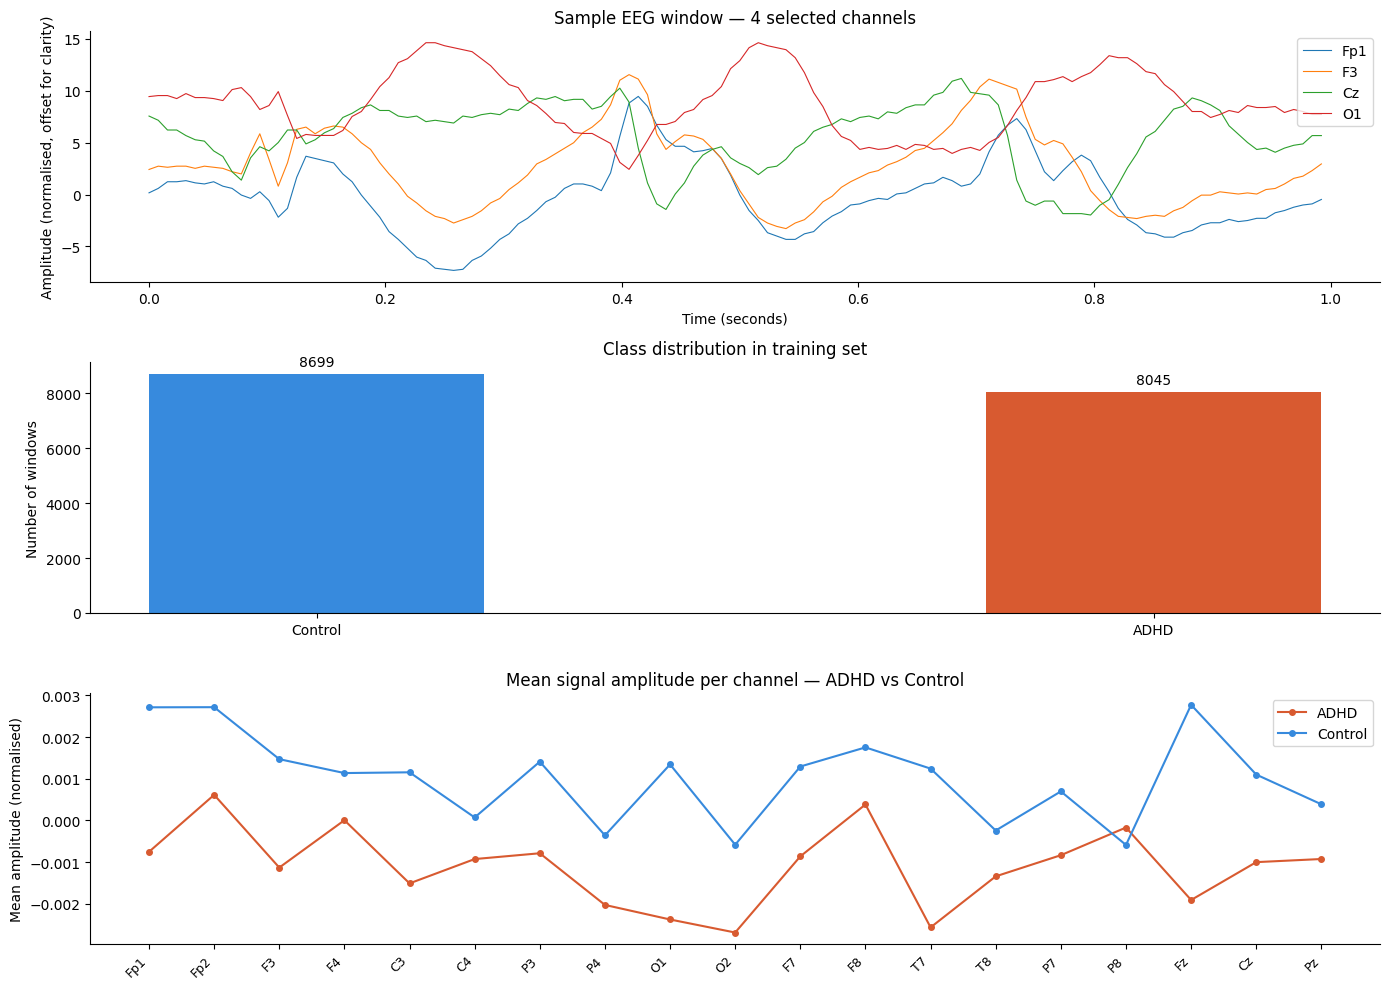

Plot saved.


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# ── Plot 1: raw EEG sample (one window, 4 channels) ──
ax = axes[0]
sample_window = X_train[0]  # shape (128, 19)
for i, ch in enumerate(['Fp1', 'F3', 'Cz', 'O1']):
    ch_idx = CHANNELS.index(ch)
    ax.plot(np.arange(WINDOW_SIZE) / 128,
            sample_window[:, ch_idx] + i * 3,  # offset for visibility
            label=ch, linewidth=0.8)
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Amplitude (normalised, offset for clarity)')
ax.set_title('Sample EEG window — 4 selected channels')
ax.legend(loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

# ── Plot 2: class distribution ──
ax = axes[1]
labels = ['Control', 'ADHD']
counts = [(y_train == 0).sum(), (y_train == 1).sum()]
bars = ax.bar(labels, counts, color=['#378ADD', '#D85A30'], width=0.4)
ax.bar_label(bars, padding=4)
ax.set_ylabel('Number of windows')
ax.set_title('Class distribution in training set')
ax.spines[['top', 'right']].set_visible(False)

# ── Plot 3: mean signal per class across all channels ──
ax = axes[2]
adhd_mean    = X_train[y_train == 1].mean(axis=(0, 1))  # mean per channel
control_mean = X_train[y_train == 0].mean(axis=(0, 1))
x = np.arange(len(CHANNELS))
ax.plot(x, adhd_mean,    marker='o', markersize=4, label='ADHD',    color='#D85A30')
ax.plot(x, control_mean, marker='o', markersize=4, label='Control', color='#378ADD')
ax.set_xticks(x)
ax.set_xticklabels(CHANNELS, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean amplitude (normalised)')
ax.set_title('Mean signal amplitude per channel — ADHD vs Control')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## 3. Models
We train three models of increasing complexity:
- MLP (baseline): treats each window as a flat vector, ignores temporal structure
- 1D CNN: learns local temporal and spatial features across channels
- LSTM: captures long-range temporal dependencies in the signal

In [8]:
# MLP input: flatten (128, 19) → (2432,)
X_train_mlp = X_train.reshape(len(X_train), -1)
X_val_mlp   = X_val.reshape(len(X_val), -1)
X_test_mlp  = X_test.reshape(len(X_test), -1)

# CNN and LSTM input: keep (128, 19) as-is
X_train_seq = X_train
X_val_seq   = X_val
X_test_seq  = X_test

print("MLP input shape:", X_train_mlp.shape)
print("CNN/LSTM input shape:", X_train_seq.shape)

MLP input shape: (16744, 2432)
CNN/LSTM input shape: (16744, 128, 19)


In [9]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['loss'],     label='Train loss')
    axes[0].plot(history.history['val_loss'], label='Val loss')
    axes[0].set_title(f'{model_name} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].spines[['top', 'right']].set_visible(False)

    axes[1].plot(history.history['accuracy'],     label='Train accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Val accuracy')
    axes[1].set_title(f'{model_name} — Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ", "_")}_history.png', dpi=150, bbox_inches='tight')
    plt.show()

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()

    print(f"\n── {model_name} — Test results ──")
    print(classification_report(y_test, y_pred, target_names=['Control', 'ADHD']))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Control', 'ADHD'],
                yticklabels=['Control', 'ADHD'])
    plt.title(f'{model_name} — Confusion matrix')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ", "_")}_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()

    return y_pred

Model: "MLP_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       622,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 665,601 (2.54 MB)

 Trainable params: 664,833 (2.54 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.6489 - loss: 0.6404 - val_accuracy: 0.7819 - val_loss: 0.5000
Epoch 2/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.7822 - loss: 0.4531 - val_accuracy: 0.8283 - val_loss: 0.3957
Epoch 3/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 35s 110ms/step - accuracy: 0.8375 - loss: 0.3633 - val_accuracy: 0.8230 - val_loss: 0.3886
Epoch 4/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 53s 152ms/step - accuracy: 0.8675 - loss: 0.2984 - val_accuracy: 0.8289 - val_loss: 0.3738
Epoch 5/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 41s 139ms/step - accuracy: 0.8907 - loss: 0.2550 - val_accuracy: 0.8283 - val_loss: 0.3692
Epoch 6/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 50s 165ms/step - accuracy: 0.9065 - loss: 0.2214 - val_accuracy: 0.7991 - val_loss: 0.4464
Epoch 7/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 52s 46ms/step - accuracy: 0.9196 - loss: 0.1991 - val_accuracy: 0.8236 - val_loss: 0.3953
Epoch 8/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.9256 - loss: 0.183

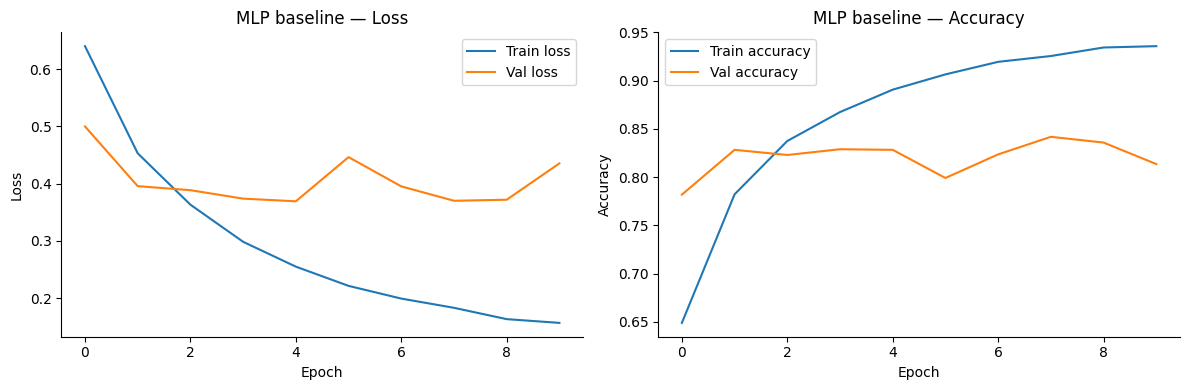


── MLP baseline — Test results ──
              precision    recall  f1-score   support

     Control       0.76      0.71      0.74      1798
        ADHD       0.74      0.78      0.76      1855

    accuracy                           0.75      3653
   macro avg       0.75      0.75      0.75      3653
weighted avg       0.75      0.75      0.75      3653



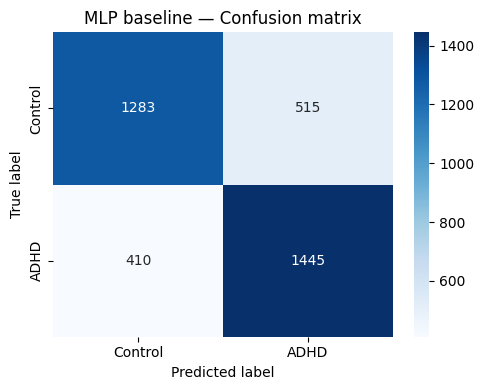

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

# ── build ──
mlp = keras.Sequential([
    layers.Input(shape=(X_train_mlp.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
], name='MLP_baseline')

mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
mlp.summary()

# ── train ──
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

mlp_history = mlp.fit(
    X_train_mlp, y_train,
    validation_data=(X_val_mlp, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# ── evaluate ──
plot_history(mlp_history, 'MLP baseline')
mlp_preds = evaluate_model(mlp, X_test_mlp, y_test, 'MLP baseline')

# ── save ──
#mlp.save('/content/drive/MyDrive/ACML_Project/mlp_model.keras')
#print("MLP saved.")

### Model 2: 1D CNN
Applies convolutional filters across the time dimension to learn local temporal
and cross-channel patterns. Input shape: (128, 19).

Model: "1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 64)        │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 32, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 16, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 180,609 (705.50 KB)

 Trainable params: 179,713 (702.00 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 146s 501ms/step - accuracy: 0.9374 - loss: 0.1453 - val_accuracy: 0.7649 - val_loss: 0.7225
Epoch 2/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 167s 593ms/step - accuracy: 0.9911 - loss: 0.0246 - val_accuracy: 0.8340 - val_loss: 0.7005
Epoch 3/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 242s 748ms/step - accuracy: 0.9928 - loss: 0.0212 - val_accuracy: 0.8045 - val_loss: 0.8818
Epoch 4/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 222s 822ms/step - accuracy: 0.9950 - loss: 0.0140 - val_accuracy: 0.8151 - val_loss: 0.8444
Epoch 5/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 240s 732ms/step - accuracy: 0.9939 - loss: 0.0182 - val_accuracy: 0.8098 - val_loss: 0.8594
Epoch 6/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 227s 827ms/step - accuracy: 0.9974 - loss: 0.0074 - val_accuracy: 0.8123 - val_loss: 1.0133
Epoch 7/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 285s 908ms/step - accuracy: 0.9954 - loss: 0.0132 - val_accuracy: 0.8537 - val_loss: 0.5895
Epoch 8/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 294s 1s/step - accuracy: 0.9975 - lo

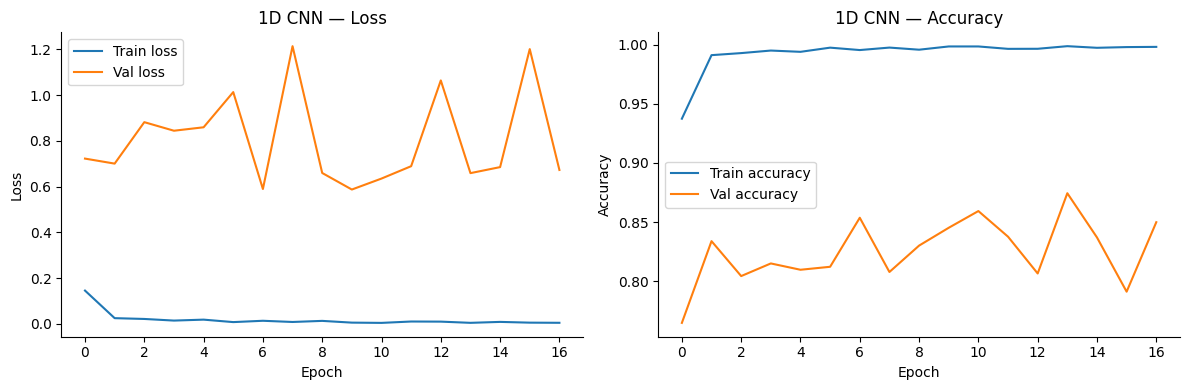


── 1D CNN — Test results ──
              precision    recall  f1-score   support

     Control       0.77      0.85      0.81      1798
        ADHD       0.84      0.75      0.79      1855

    accuracy                           0.80      3653
   macro avg       0.80      0.80      0.80      3653
weighted avg       0.80      0.80      0.80      3653



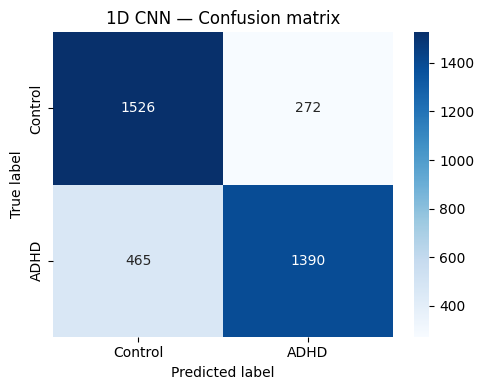

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ACML_Project/cnn_model.keras'

In [ ]:
cnn = keras.Sequential([
    layers.Input(shape=(WINDOW_SIZE, 19)),

    # block 1
    layers.Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),

    # block 2
    layers.Conv1D(filters=128, kernel_size=5, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),

    # block 3
    layers.Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),

    # classification head
    layers.GlobalAveragePooling1D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
], name='1D_CNN')

cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn.summary()

# ── train ──
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

cnn_history = cnn.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# ── evaluate ──
plot_history(cnn_history, '1D CNN')
cnn_preds = evaluate_model(cnn, X_test_seq, y_test, '1D CNN')

# ── save ──
#cnn.save('/content/drive/MyDrive/ACML_Project/cnn_model.keras')
print("CNN saved.")

### Model 3: LSTM
Processes the EEG window as a sequence, maintaining hidden state across
time steps to capture long-range temporal dependencies. Input shape: (128, 19).

In [ ]:
lstm = keras.Sequential([
    layers.Input(shape=(WINDOW_SIZE, 19)),

    # first LSTM layer — return sequences for stacking
    layers.LSTM(128, return_sequences=True),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # second LSTM layer — return final hidden state only
    layers.LSTM(64, return_sequences=False),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # classification head
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
], name='LSTM')

lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm.summary()

# ── train ──
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

lstm_history = lstm.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# ── evaluate ──
plot_history(lstm_history, 'LSTM')
lstm_preds = evaluate_model(lstm, X_test_seq, y_test, 'LSTM')

# ── save ──
#lstm.save('/content/drive/MyDrive/ACML_Project/lstm_model.keras')
#print("LSTM saved.")

### Model 4: CNN-LSTM hybrid
Uses CNN layers to extract local temporal features, then passes the
feature sequence to an LSTM to capture higher-level temporal patterns.
This addresses the LSTM's difficulty learning directly from raw EEG.

In [ ]:
cnn_lstm = keras.Sequential([
    layers.Input(shape=(WINDOW_SIZE, 19)),

    # CNN feature extraction
    layers.Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),

    layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),

    # LSTM temporal modelling on CNN features
    layers.LSTM(64, return_sequences=False),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # classification head
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
], name='CNN_LSTM')

cnn_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_lstm.summary()

# ── train ──
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

cnn_lstm_history = cnn_lstm.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# ── evaluate ──
plot_history(cnn_lstm_history, 'CNN-LSTM')
cnn_lstm_preds = evaluate_model(cnn_lstm, X_test_seq, y_test, 'CNN-LSTM')

# ── save ──
#cnn_lstm.save('/content/drive/MyDrive/ACML_Project/cnn_lstm_model.keras')
#print("CNN-LSTM saved.")

In [ ]:
# ── summary table ──
results = {
    'Model':     ['MLP', '1D CNN', 'LSTM', 'CNN-LSTM'],
    'Params':    [665_601, 180_609, 130_177, 85_505],
    'Test Acc':  [0.76, 0.83, 0.73, 0.85],
    'F1 Control':[0.75, 0.83, 0.76, 0.85],
    'F1 ADHD':   [0.78, 0.83, 0.69, 0.85],
    'Macro F1':  [0.76, 0.83, 0.72, 0.85],
}
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# ── bar chart comparison ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models  = results['Model']
colors  = ['#888780', '#378ADD', '#D85A30', '#1D9E75']
x       = np.arange(len(models))
width   = 0.5

# accuracy
bars = axes[0].bar(x, results['Test Acc'], width=width, color=colors)
axes[0].bar_label(bars, fmt='%.2f', padding=4, fontsize=10)
axes[0].set_xticks(x); axes[0].set_xticklabels(models)
axes[0].set_ylim(0.60, 0.95)
axes[0].set_ylabel('Test accuracy')
axes[0].set_title('Test accuracy by model')
axes[0].spines[['top', 'right']].set_visible(False)

# macro F1
bars2 = axes[1].bar(x, results['Macro F1'], width=width, color=colors)
axes[1].bar_label(bars2, fmt='%.2f', padding=4, fontsize=10)
axes[1].set_xticks(x); axes[1].set_xticklabels(models)
axes[1].set_ylim(0.60, 0.95)
axes[1].set_ylabel('Macro F1 score')
axes[1].set_title('Macro F1 score by model')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Model comparison — EEG ADHD classification', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── parameter efficiency plot ──
fig, ax = plt.subplots(figsize=(7, 5))
for i, (m, p, a, c) in enumerate(zip(models, results['Params'], results['Test Acc'], colors)):
    ax.scatter(p, a, s=120, color=c, zorder=3, label=m)
    ax.annotate(m, (p, a), textcoords='offset points', xytext=(8, 4), fontsize=10)

ax.set_xlabel('Number of parameters')
ax.set_ylabel('Test accuracy')
ax.set_title('Parameter efficiency — accuracy vs model size')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('parameter_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def run_window_experiment(df, window_size, step_size, max_windows=200):
    """Rebuild dataset with a different window size and evaluate CNN-LSTM."""

    X_exp, y_exp, ids_exp = [], [], []

    for subject_id, group in df.groupby('ID'):
        label = 1 if group['Class'].iloc[0] == 'ADHD' else 0
        signal = group[CHANNELS].values.astype(np.float32)
        signal = (signal - signal.mean(axis=0)) / (signal.std(axis=0) + 1e-8)

        windows = []
        for start in range(0, len(signal) - window_size, step_size):
            windows.append(signal[start : start + window_size])

        if len(windows) > max_windows:
            indices = np.random.choice(len(windows), max_windows, replace=False)
            windows = [windows[i] for i in sorted(indices)]

        X_exp.extend(windows)
        y_exp.extend([label] * len(windows))
        ids_exp.extend([subject_id] * len(windows))

    X_exp = np.array(X_exp)
    y_exp = np.array(y_exp)
    ids_exp = np.array(ids_exp)

    # reuse same subject splits
    X_tr = X_exp[np.isin(ids_exp, train_subjects)]
    y_tr = y_exp[np.isin(ids_exp, train_subjects)]
    X_v  = X_exp[np.isin(ids_exp, val_subjects)]
    y_v  = y_exp[np.isin(ids_exp, val_subjects)]
    X_te = X_exp[np.isin(ids_exp, test_subjects)]
    y_te = y_exp[np.isin(ids_exp, test_subjects)]

    # build fresh CNN-LSTM with correct input shape
    model = keras.Sequential([
        layers.Input(shape=(window_size, 19)),
        layers.Conv1D(64,  kernel_size=5, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),
        layers.Dropout(0.3),
        layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),
        layers.Dropout(0.3),
        layers.LSTM(64),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
              epochs=50, batch_size=64, callbacks=[es], verbose=0)

    y_pred = (model.predict(X_te, verbose=0) > 0.5).astype(int).flatten()
    acc = (y_pred == y_te).mean()
    from sklearn.metrics import f1_score
    f1 = f1_score(y_te, y_pred, average='macro')

    duration_s = window_size / 128
    print(f"Window {window_size:4d} samples ({duration_s:.2f}s) — "
          f"Acc: {acc:.4f}  Macro F1: {f1:.4f}  "
          f"Train windows: {len(X_tr)}")
    return acc, f1

# run across three window sizes (128 already done — reuse those results)
print("Running window size experiment on CNN-LSTM...")
print("─" * 65)

window_configs = [64, 128, 256]  # 0.5s, 1s, 2s
accs, f1s = [], []

for ws in window_configs:
    acc, f1 = run_window_experiment(df, window_size=ws, step_size=ws//2)
    accs.append(acc)
    f1s.append(f1)

# ── plot results ──
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels = ['0.5s (64)', '1.0s (128)', '2.0s (256)']
colors_ws = ['#B5D4F4', '#378ADD', '#0C447C']

for ax, vals, title in zip(axes,
                            [accs, f1s],
                            ['Test accuracy', 'Macro F1 score']):
    bars = ax.bar(labels, vals, color=colors_ws, width=0.5)
    ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=10)
    ax.set_ylim(0.70, 0.95)
    ax.set_xlabel('Window size')
    ax.set_ylabel(title)
    ax.set_title(f'CNN-LSTM — {title} by window size')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Hyperparameter experiment: window size', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('window_size_experiment.png', dpi=150, bbox_inches='tight')
plt.show()